In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys, pathlib
# adjust this to your repo root if different
repo_root = pathlib.Path('/home/ubuntu/qecsim-1').resolve()
sys.path.insert(0, str(repo_root))
print('Inserted repo root into sys.path:', repo_root)

Inserted repo root into sys.path: C:\home\ubuntu\qecsim-1


In [3]:
from qecsim.tools.qem_estimator.calc_ptm import calc_ptm
from qecsim.codes.lattice_surgery.builder import surgery_circuit
from qecsim.tools.qem_estimator.logical_estimator import logical_estimator
from qecsim.codes.surface_code_rotated.builder import rotated_surface_code

In [4]:
noise = 0.01
distance = 3

###############
# Diag Circuits
###############
"""
For the Diagonal we can use pauli frames -> Only need 3 isntead of 6
"""
c_0_z = rotated_surface_code(distance= distance, 
                             rounds= distance, 
                             log_obs= "Z", 
                             state_init= "0", 
                             noise_after_clifford_depol= noise, 
                             noise_after_reset= noise, 
                             noise_depol_data_init= noise, 
                             noise_measure_flip= noise)
c_p_x = rotated_surface_code(distance= distance,
                            rounds= distance, 
                            log_obs= "X", 
                            state_init= "+", 
                            noise_after_clifford_depol= noise, 
                            noise_after_reset= noise, 
                            noise_depol_data_init= noise, 
                            noise_measure_flip= noise)
c_pi_y = rotated_surface_code(distance= distance, 
                           rounds= distance, 
                           log_obs= "Y", 
                           state_init= "+i", 
                           noise_after_clifford_depol= noise, 
                           noise_after_reset= noise, 
                           noise_depol_data_init= noise, 
                           noise_measure_flip= noise)

###################
# Off-Diag Circuits
###################
"""
We need full physical (Noiseless) Implementation of the logical state we want to initilize
-> Rec pos stay the same so can be reused (Measurement indexes wont change -> No new measurements)

We have 6 non diag entries with either needign 2 circs -> 12 circs in total
"""
c_0_x, rec_pos_log_x = rotated_surface_code(distance= distance, 
                                            rounds= distance, 
                                            log_obs= "X", 
                                            state_init= "0", 
                                            noise_after_clifford_depol= noise, 
                                            noise_after_reset= noise, 
                                            noise_depol_data_init= noise, 
                                            noise_measure_flip= noise)
c_1_x, rec_pos_log_x = rotated_surface_code(distance= distance, 
                                            rounds= distance, 
                                            log_obs= "X", 
                                            state_init= "1", 
                                            noise_after_clifford_depol= noise, 
                                            noise_after_reset= noise, 
                                            noise_depol_data_init= noise, 
                                            noise_measure_flip= noise)
c_pi_x, rec_pos_log_x_pi = rotated_surface_code(distance= distance, 
                                                rounds= distance, 
                                                log_obs= "X", 
                                                state_init= "+i", 
                                                noise_after_clifford_depol= noise, 
                                                noise_after_reset= noise, 
                                                noise_depol_data_init= noise, 
                                                noise_measure_flip= noise)
c_mi_x, rec_pos_log_x_pi = rotated_surface_code(distance= distance, 
                                                rounds= distance, 
                                                log_obs= "X", 
                                                state_init= "-i", 
                                                noise_after_clifford_depol= noise, 
                                                noise_after_reset= noise, 
                                                noise_depol_data_init= noise, 
                                                noise_measure_flip= noise)
c_p_z, rec_pos_log_z = rotated_surface_code(distance= distance, 
                                            rounds= distance, 
                                            log_obs= "Z", 
                                            state_init= "+", 
                                            noise_after_clifford_depol= noise, 
                                            noise_after_reset= noise, 
                                            noise_depol_data_init= noise, 
                                            noise_measure_flip= noise)
c_m_z, rec_pos_log_z = rotated_surface_code(distance= distance, 
                                            rounds= distance, 
                                            log_obs= "Z", 
                                            state_init= "-", 
                                            noise_after_clifford_depol= noise, 
                                            noise_after_reset= noise, 
                                            noise_depol_data_init= noise, 
                                            noise_measure_flip= noise)
c_pi_z, rec_pos_log_z_pi = rotated_surface_code(distance= distance, 
                                                rounds= distance, 
                                                log_obs= "Z", 
                                                state_init= "+i", 
                                                noise_after_clifford_depol= noise, 
                                                noise_after_reset= noise, 
                                                noise_depol_data_init= noise, 
                                                noise_measure_flip= noise)
c_mi_z, rec_pos_log_z_pi = rotated_surface_code(distance= distance, 
                                                rounds= distance, 
                                                log_obs= "Z", 
                                                state_init= "-i", 
                                                noise_after_clifford_depol= noise, 
                                                noise_after_reset= noise, 
                                                noise_depol_data_init= noise, 
                                                noise_measure_flip= noise)
c_0_y, rec_pos_log_y0 = rotated_surface_code(distance= distance, 
                                             rounds= distance, 
                                             log_obs= "Y", 
                                             state_init= "0", 
                                             noise_after_clifford_depol= noise, 
                                             noise_after_reset= noise, 
                                             noise_depol_data_init= noise, 
                                             noise_measure_flip= noise)
c_1_y, rec_pos_log_y0 = rotated_surface_code(distance= distance, 
                                             rounds= distance, 
                                             log_obs= "Y", 
                                             state_init= "1", 
                                             noise_after_clifford_depol= noise, 
                                             noise_after_reset= noise, 
                                             noise_depol_data_init= noise, 
                                             noise_measure_flip= noise)
c_p_y, rec_pos_log_yp = rotated_surface_code(distance= distance, 
                                             rounds= distance, 
                                             log_obs= "Y", 
                                             state_init= "+", 
                                             noise_after_clifford_depol= noise, 
                                             noise_after_reset= noise, 
                                             noise_depol_data_init= noise, 
                                             noise_measure_flip= noise)
c_m_y, rec_pos_log_yp = rotated_surface_code(distance= distance, 
                                             rounds= distance, 
                                             log_obs= "Y", 
                                             state_init= "-", 
                                             noise_after_clifford_depol= noise, 
                                             noise_after_reset= noise, 
                                             noise_depol_data_init= noise, 
                                             noise_measure_flip= noise)

1 -> _______________Z_
1 -> ______________Z__
1 -> _____________Z___
1 -> _________Z_______
1 -> ________Z________
1 -> _______Z_________
1 -> ___Z_____________
1 -> __Z______________
1 -> _Z_______________
X16 -> X16
Z16 -> Z16
____________X____ -> ____________X____
____________Z____ -> ____________Z____
___________X_____ -> ___________X_____
___________Z_____ -> ___________Z_____
__________X______ -> __________X______
__________Z______ -> __________Z______
______X__________ -> ______X__________
______Z__________ -> ______Z__________
_____X___________ -> _____X___________
_____Z___________ -> _____Z___________
____X____________ -> ____X____________
____Z____________ -> ____Z____________
X________________ -> X________________
Z________________ -> Z________________
1 -> _______________X_
1 -> ______________X__
1 -> _____________X___
1 -> _________X_______
1 -> ________X________
1 -> _______X_________
1 -> ___X_____________
1 -> __X______________
1 -> _X_______________
X16 -> X16
Z16 -> 

ValueError: too many values to unpack (expected 2)

In [ ]:
c_m_y

In [ ]:
#################
# Calculating PTM
#################

PTM= calc_ptm(circuit_0_z= c_0_z,
              circuit_p_z= c_p_z,
              circuit_m_z= c_m_z,
              circuit_pi_z= c_pi_z,
              circuit_mi_z= c_mi_z,
              circuit_0_x= c_0_x,
              circuit_1_x= c_1_x, 
              circuit_p_x= c_p_x,
              circuit_pi_x= c_pi_x,
              circuit_mi_x= c_mi_x,
              circuit_pi_y= c_pi_y,
              circuit_0_y= c_0_y, 
              circuit_1_y= c_1_y,
              circuit_p_y= c_p_y,
              circuit_m_y= c_m_y, 
              rec_pos_log_y01= rec_pos_log_y0, 
              rec_pos_log_ypm= rec_pos_log_yp,
              rec_pos_log_x = rec_pos_log_x, 
              rec_pos_log_z = rec_pos_log_z,
              rec_pos_log_x_pmi= rec_pos_log_x_pi, 
              rec_pos_log_z_pmi= rec_pos_log_z_pi,
              samples = 10_000)
PTM

In [ ]:
# For testing create Diagonal PTM
import numpy as np

def diag_ptm(ptm: np.ndarray) -> np.ndarray:

    ptm_diag = [
            [ptm[0,0], 0.0, 0.0], 
            [0.0, ptm[0,0], 0.0], 
            [0.0, 0.0, ptm[0,0]]]

    return(np.array(ptm_diag))

In [ ]:
#################################
# Test Estimator on Memory Rounds
#################################
memory_z = c_0_z
memory_x = c_p_x
memory_y = c_pi_y

ptm_diag = diag_ptm(PTM)

fll_sol = logical_estimator(ptm= PTM,
                  ptm_circuit_x= memory_x,
                  ptm_circuit_y= memory_y,
                  ptm_circuit_z= memory_z,
                  logical_obs = "X", 
                  frame_flip= False, 
                  shots = 80_000)

diag_sol = logical_estimator(ptm= ptm_diag,
                  ptm_circuit_x= memory_x,
                  ptm_circuit_y= memory_y,
                  ptm_circuit_z= memory_z,
                  logical_obs = "X", 
                  frame_flip= False, 
                  shots = 80_000)

print(fll_sol, diag_sol)

In [ ]:
distance = 3
noise = 0.1

########
# ONLY X
########

circ_IX_IX_p = surgery_circuit(distance = distance, 
                            target_state_init="X+", 
                            control_state_init="X+", 
                            flow_observable="X -> X",
                            noise_depol_data_init= noise,
                            noise_after_clifford_depol= noise,
                            noise_after_reset= noise,
                            noise_measure_flip= noise)

circ_XI_XX_p = surgery_circuit(distance = distance, 
                            target_state_init="X+", 
                            control_state_init="X+", 
                            flow_observable="X -> XX",
                            noise_depol_data_init= noise,
                            noise_after_clifford_depol= noise,
                            noise_after_reset= noise,
                            noise_measure_flip= noise)

circ_XX_XI_p = surgery_circuit(distance = distance, 
                            target_state_init="X+", 
                            control_state_init="X+", 
                            flow_observable="XX -> X",
                            noise_depol_data_init= noise,
                            noise_after_clifford_depol= noise,
                            noise_after_reset= noise,
                            noise_measure_flip= noise)

########
# ONLY Y
########



########
# ONLY Z
########

circ_ZI_ZI_p = surgery_circuit(distance = distance, 
                            target_state_init="Z0", 
                            control_state_init="Z0", 
                            flow_observable="Z -> Z",
                            noise_depol_data_init= noise,
                            noise_after_clifford_depol= noise,
                            noise_after_reset= noise,
                            noise_measure_flip= noise)

circ_IZ_ZZ_p = surgery_circuit(distance = distance, 
                            target_state_init="Z0", 
                            control_state_init="Z0", 
                            flow_observable="Z -> ZZ",
                            noise_depol_data_init= noise,
                            noise_after_clifford_depol= noise,
                            noise_after_reset= noise,
                            noise_measure_flip= noise)

circ_ZZ_IZ_p = surgery_circuit(distance = distance, 
                            target_state_init="Z0", 
                            control_state_init="Z0", 
                            flow_observable="ZZ -> Z",
                            noise_depol_data_init= noise,
                            noise_after_clifford_depol= noise,
                            noise_after_reset= noise,
                            noise_measure_flip= noise)

#############
# Mixed Terms
#############

circ_ZX_ZX_p = surgery_circuit(distance = distance, 
                            target_state_init="X+", 
                            control_state_init="Z0", 
                            flow_observable="ZX -> ZX",
                            noise_depol_data_init= noise,
                            noise_after_clifford_depol= noise,
                            noise_after_reset= noise,
                            noise_measure_flip= noise)


In [ ]:
surgery_circuit(distance=3, target_state_init="Z1", control_state_init="Y-", flow_observable="YZ -> XY").diagram("detslice-with-ops-svg", filter_coords="L0")

: 

1 -> Z16 xor rec[7]
1 -> ______________ZZ_ xor rec[7]
1 -> ____________Z____ xor rec[1]
1 -> ___________Z_____ xor rec[5]
1 -> __________Z______ xor rec[3]
1 -> ________XX____XX_ xor rec[1]
1 -> _______X_____X___ xor rec[3]
1 -> _______ZZ____Z_Z_ xor rec[5] xor rec[7]
1 -> ______Z__________ xor rec[2]
1 -> _____Z___________ xor rec[4]
1 -> ____Z____________ xor rec[0]
1 -> ___X_____X_______ xor rec[2]
1 -> __ZZ____ZZ_______ xor rec[4]
1 -> _XX______X___XXX_ xor rec[0] xor rec[1] xor rec[3]
1 -> _Z_Z____ZZ_______ xor rec[4] xor rec[6]
1 -> Z________________ xor rec[6]
______________ZZ_ -> rec[7]
_____________XXX_ -> _____________XXX_
________XX____XX_ -> rec[1]
_______X______XX_ -> _____________XXX_ xor rec[3]
_______ZZ____Z_Z_ -> rec[5] xor rec[7]
___X_____X_______ -> rec[2]
___Z_____Z_____Z_ -> ___Z_____Z_____Z_
__Z_____Z______Z_ -> ___Z_____Z_____Z_ xor rec[4]
_XX______X_______ -> _____________XXX_ xor rec[0] xor rec[1] xor rec[3]
_Z______Z______Z_ -> ___Z_____Z_____Z_ xor rec[4] xor

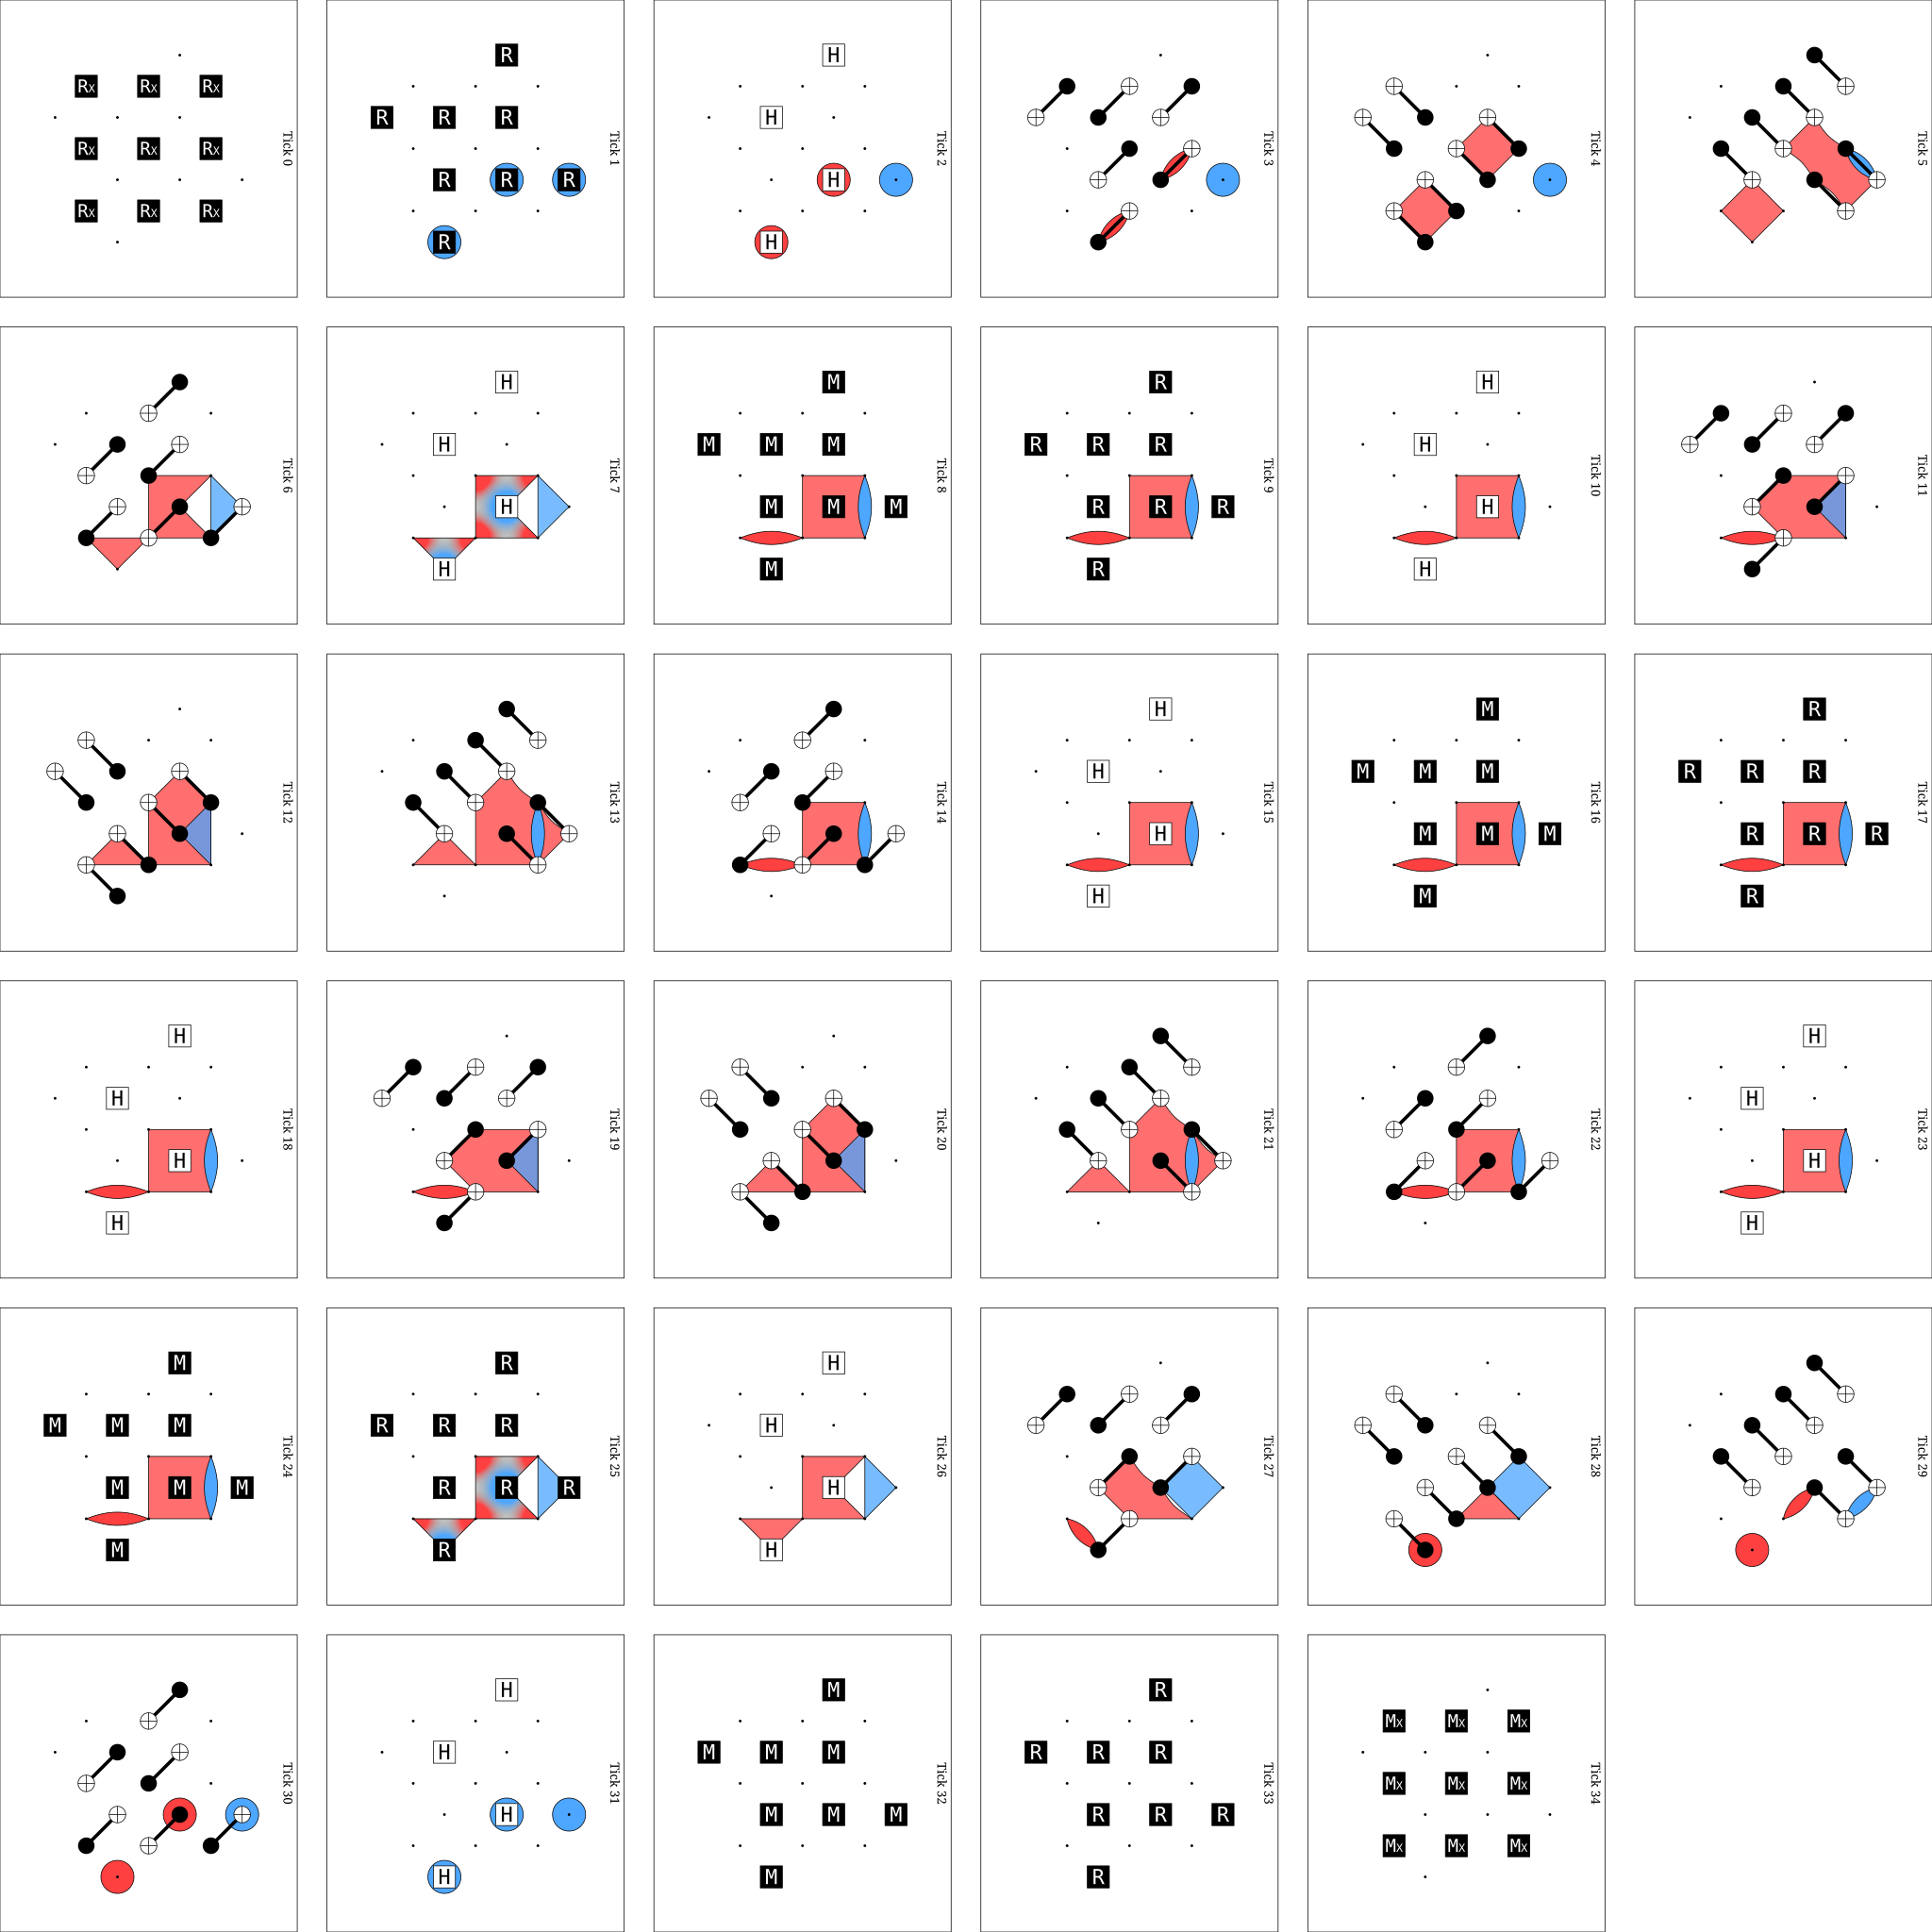

In [59]:
rotated_surface_code(distance= 3, 
                             rounds= 4, 
                             log_obs= "X", 
                             state_init= "+").diagram("detslice-with-ops-svg")

In [105]:
import stim
from qecsim.core.add_noise import CircuitNoise, BiasNoise
from qecsim.codes.xzzx.builder import xzzx_code

test_xzzx = xzzx_code(distance=3,
                      rounds=3,
                      state_init="Ver",
                      )

circuit_noise = {
    "after_c_depol_prob": 0.1,
    "after_r_flip": 0.2,
    "before_round_depol": 0.3,
    "before_m_flip_prob": 0.4
}

circuit_biased_noise = {"bias": [1,0,0], 
                        "after_c_custom_noise": 0.4
                        }

noisy_circ_class = CircuitNoise(test_xzzx, noise = circuit_noise)
noisy_circ = noisy_circ_class.apply()
noisy_circ_biased = BiasNoise(noisy_circ, noise = circuit_biased_noise)
noisy_circ_biased = noisy_circ_biased.apply()

noisy_circ_biased

stim.Circuit('''
    QUBIT_COORDS(0, 2) 0
    QUBIT_COORDS(1, 1) 1
    QUBIT_COORDS(1, 3) 2
    QUBIT_COORDS(1, 5) 3
    QUBIT_COORDS(2, 2) 4
    QUBIT_COORDS(2, 4) 5
    QUBIT_COORDS(2, 6) 6
    QUBIT_COORDS(3, 1) 7
    QUBIT_COORDS(3, 3) 8
    QUBIT_COORDS(3, 5) 9
    QUBIT_COORDS(4, 0) 10
    QUBIT_COORDS(4, 2) 11
    QUBIT_COORDS(4, 4) 12
    QUBIT_COORDS(5, 1) 13
    QUBIT_COORDS(5, 3) 14
    QUBIT_COORDS(5, 5) 15
    QUBIT_COORDS(6, 4) 16
    R 2 7 9 14
    X_ERROR(0.2) 2 7 9 14
    RX 1 3 8 13 15
    X_ERROR(0.2) 1 3 8 13 15
    TICK
    R 0 4 5 6 10 11 12 16
    X_ERROR(0.2) 0 4 5 6 10 11 12 16
    TICK
    H 0 4 5 6 10 11 12 16
    PAULI_CHANNEL_1(0.4, 0, 0) 0 4 5 6 10 11 12 16
    DEPOLARIZE1(0.1) 0 4 5 6 10 11 12 16
    TICK
    CX 4 1 5 2 11 7 12 8 16 14 6 3
    PAULI_CHANNEL_2(0.133333, 0, 0, 0.133333, 0.133333, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0) 4 1 5 2 11 7 12 8 16 14 6 3
    DEPOLARIZE2(0.1) 4 1 5 2 11 7 12 8 16 14 6 3
    TICK
    CZ 4 7 5 8 11 13 12 14 16 15 6 9
    PAULI_